# Comparing correction methods

Run every MaldiBatchKit corrector on the same dataset and compare them on three batch-mixing metrics (silhouette, kBET acceptance, LISI) plus per-batch peak-position drift.

Uses the **MALDI-Kleb-AI** dataset (Rocchi *et al.*, 2026; [Zenodo DOI 10.5281/zenodo.17405072](https://zenodo.org/records/17405072)); see notebook 01 for caching details.


## 1. Load the dataset


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from notebooks._demo import load_maldi_kleb_ai

ds = load_maldi_kleb_ai(antibiotic='Amikacin')
print('X:', ds.X.shape, '| batches:', ds.batch.value_counts().to_dict())
ds.meta.head()

X: (741, 6000) | batches: {'Rome': 470, 'Milan': 184, 'Catania': 87}


,Amikacin,Meropenem,Species,Batch,SNR
1-8317003599,S,S,Klebsiella pneumoniae,Milan,128.163340
10-8320002130,S,S,Klebsiella pneumoniae,Milan,128.492364
100-8660007296,S,S,Klebsiella pneumoniae,Milan,149.638040
1004,R,R,Klebsiella pneumoniae,Rome,70.134876
101-8140000209,S,S,Klebsiella pneumoniae,Milan,84.646561


## 2. Baseline metrics (no correction)


In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from maldibatchkit.diagnostics import silhouette_batch, kbet, lisi

def summarise(X):
    return {
        'silhouette': silhouette_batch(X, ds.batch),
        'kbet_acc': kbet(X, ds.batch)['acceptance_rate'],
        'lisi': lisi(X, ds.batch, perplexity=30.0),
    }

baseline = summarise(ds.X)
baseline

{'silhouette': 0.1474570958800467,
 'kbet_acc': 0.020242914979757085,
 'lisi': 1.0145424511187204}

## 3. Run every corrector


In [3]:
from maldibatchkit import (
    ComBat, Limma, Harmony,
    MedianCentering, ZScorePerBatch, ReferenceScaling,
    QualityWeightedComBat, SpeciesAwareComBat,
)

pipelines = {
    'ComBat (Johnson)': lambda: ComBat(batch=ds.batch, method='johnson'),
    'ComBat (Fortin + species)': lambda: SpeciesAwareComBat(batch=ds.batch, species=ds.species),
    'ComBat (Chen / CovBat)': lambda: ComBat(
        batch=ds.batch, method='chen',
        discrete_covariates=ds.species, covbat_cov_thresh=0.9,
    ),
    'Quality-weighted ComBat': lambda: QualityWeightedComBat(batch=ds.batch, quality=ds.quality),
    'Limma': lambda: Limma(batch=ds.batch),
    'Harmony': lambda: Harmony(batch=ds.batch, random_state=0, max_iter=10, nclust=5, theta=4.0),
    'Median-centering': lambda: MedianCentering(batch=ds.batch),
    'Z-score per batch': lambda: ZScorePerBatch(batch=ds.batch),
    'Reference scaling': lambda: ReferenceScaling(batch=ds.batch),
}

In [4]:
rows = []
for name, build in pipelines.items():
    X_c = build().fit_transform(ds.X)
    rows.append({'method': name, **summarise(X_c)})
summary = pd.concat([
    pd.DataFrame([baseline], index=['(before)']),
    pd.DataFrame(rows).set_index('method'),
])
summary.style.format('{:.3f}')

2026-04-23 14:26:03,416 - harmonypy - INFO - Running Harmony (PyTorch on cuda)


2026-04-23 14:26:03,417 - harmonypy - INFO -   Parameters:


2026-04-23 14:26:03,417 - harmonypy - INFO -     max_iter_harmony: 10


2026-04-23 14:26:03,418 - harmonypy - INFO -     max_iter_kmeans: 20


2026-04-23 14:26:03,418 - harmonypy - INFO -     epsilon_cluster: 1e-05


...

2026-04-23 14:26:04,181 - harmonypy - INFO - Iteration 6 of 10


2026-04-23 14:26:04,209 - harmonypy - INFO - Iteration 7 of 10


2026-04-23 14:26:04,242 - harmonypy - INFO - Iteration 8 of 10


2026-04-23 14:26:04,270 - harmonypy - INFO - Converged after 8 iterations


,silhouette,kbet_acc,lisi
(before),0.147,0.020,1.015
ComBat (Johnson),-0.011,0.260,1.266
ComBat (Fortin + species),-0.015,0.267,1.238
ComBat (Chen / CovBat),-0.003,0.962,1.930
Quality-weighted ComBat,0.009,0.219,1.200
Limma,0.023,0.082,1.040
Harmony,0.001,0.422,1.384
Median-centering,0.042,0.126,1.044
Z-score per batch,-0.005,0.333,1.820
Reference scaling,0.000,0.228,1.146


## 4. Visual comparison


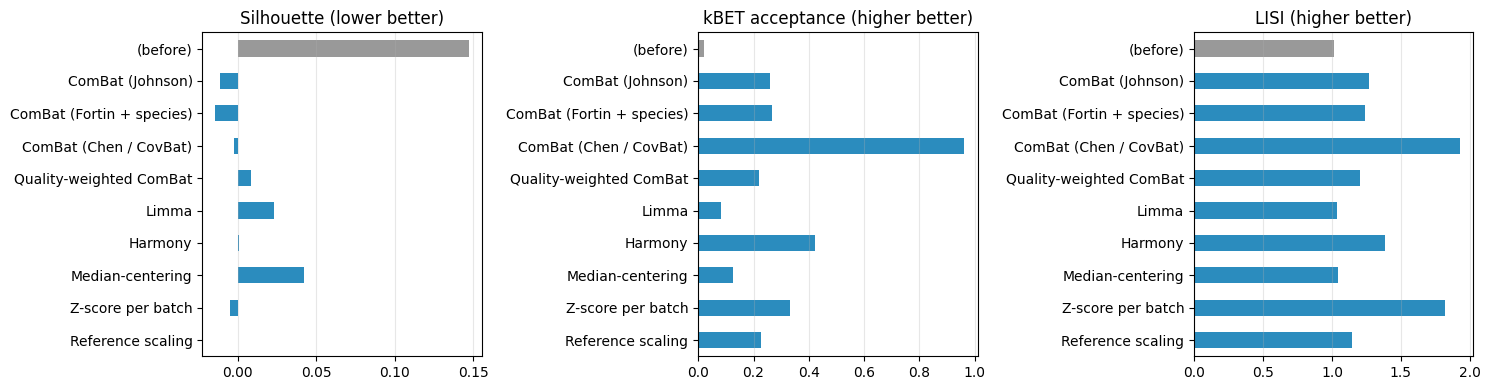

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ['silhouette', 'kbet_acc', 'lisi'],
    ['Silhouette (lower better)', 'kBET acceptance (higher better)', 'LISI (higher better)'],
    strict=True,
):
    colours = ['#999999'] + ['#2b8cbe'] * (len(summary) - 1)
    summary[col].plot.barh(ax=ax, color=colours)
    ax.set_title(title)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Per-batch peak-position drift, before vs after


In [6]:
from maldibatchkit.diagnostics import peak_position_drift

before = peak_position_drift(ds.X, ds.batch, mz_values=ds.mz, top_k=15)
combat_johnson = peak_position_drift(
    ComBat(batch=ds.batch).fit_transform(ds.X),
    ds.batch, mz_values=ds.mz, top_k=15,
)
species_combat = peak_position_drift(
    SpeciesAwareComBat(batch=ds.batch, species=ds.species).fit_transform(ds.X),
    ds.batch, mz_values=ds.mz, top_k=15,
)
pd.concat(
    {'before': before, 'ComBat (Johnson)': combat_johnson, 'Species-aware ComBat': species_combat},
    axis=1,
)

before                                  ComBat (Johnson)  \
        mean_delta_mz median_delta_mz max_abs_delta_mz    mean_delta_mz   
batch                                                                     
Catania          -1.2            -3.0              6.0              0.0   
Milan            -1.6            -3.0             12.0              0.4   
Rome             -1.2             0.0             30.0              0.2   

                                         Species-aware ComBat                  \
        median_delta_mz max_abs_delta_mz        mean_delta_mz median_delta_mz   
batch                                                                           
Catania             0.0              6.0                 -0.2             0.0   
Milan               0.0              6.0                  0.6             0.0   
Rome                0.0              3.0                 -0.6             0.0   

                          
        max_abs_delta_mz  
batch                     
Catania              3.0  
Milan                6.0  
Rome                 6.0